# Numerical validation - t-test

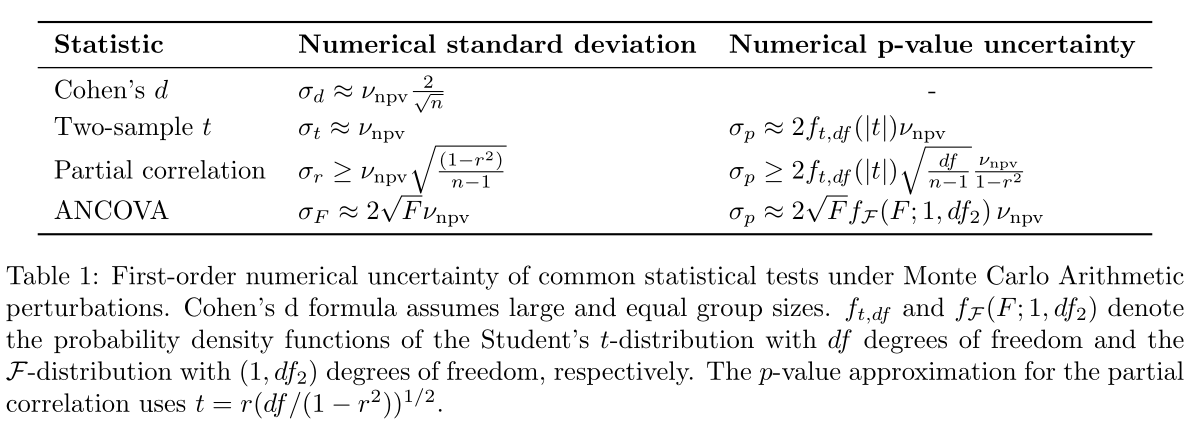

In [1]:
from IPython.display import Image
import pandas as pd
from pathlib import Path
import numpy as np
from typing import Tuple

anonymizer = True

root_dir = Path.cwd().parent.parent.parent


def anondir(path: Path, prefix=root_dir) -> Path:
    """Anonymize a directory path by replacing user-specific parts with <root>."""
    if not anonymizer:
        return path
    path_str = str(path).replace(str(prefix), "<living-park>")
    return Path(path_str)


print(f"Root directory: {anondir(root_dir)}")
input_dir = root_dir / "results" / "npvr" / "csv_all"
assert input_dir.exists(), "Input dir does not exist"
print(f"Input dir: {anondir(input_dir)}")
stats_dir = root_dir / "data" / "student"
assert stats_dir.exists(), "Stats dir does not exist"
print(f"Stats dir: {anondir(stats_dir)}")
output_dir = root_dir / "results" / "numerical_validation"
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {anondir(output_dir)}")
figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures dir: {anondir(figures_dir)}")
csv_dir = output_dir / "csv"
csv_dir.mkdir(parents=True, exist_ok=True)
print(f"CSV dir: {anondir(csv_dir)}")


Root directory: <living-park>
Input dir: <living-park>/results/npvr/csv_all
Stats dir: <living-park>/data/student
Output dir: <living-park>/results/numerical_validation
Figures dir: <living-park>/results/numerical_validation/figures
CSV dir: <living-park>/results/numerical_validation/csv


In [2]:
subcortical_regions = [
    "Left-Thalamus",
    "Left-Caudate",
    "Left-Putamen",
    "Left-Pallidum",
    "Left-Hippocampus",
    "Left-Amygdala",
    "Left-Accumbens-area",
    "Right-Thalamus",
    "Right-Caudate",
    "Right-Putamen",
    "Right-Pallidum",
    "Right-Hippocampus",
    "Right-Amygdala",
    "Right-Accumbens-area",
]

# Cortical regions in DKT atlas
cortical_regions = [
    "bankssts",
    "caudalanteriorcingulate",
    "caudalmiddlefrontal",
    "cuneus",
    "entorhinal",
    "fusiform",
    "inferiorparietal",
    "inferiortemporal",
    "isthmuscingulate",
    "lateraloccipital",
    "lateralorbitofrontal",
    "lingual",
    "medialorbitofrontal",
    "middletemporal",
    "parahippocampal",
    "paracentral",
    "parsopercularis",
    "parsorbitalis",
    "parstriangularis",
    "pericalcarine",
    "postcentral",
    "posteriorcingulate",
    "precentral",
    "precuneus",
    "rostralanteriorcingulate",
    "rostralmiddlefrontal",
    "superiorfrontal",
    "superiorparietal",
    "superiortemporal",
    "supramarginal",
    "frontalpole",
    "temporalpole",
    "transversetemporal",
    "insula",
]

In [3]:
metrics = ["area", "thickness", "volume", "subcortical_volume"]
studies = ["cross-sectional", "longitudinal"]
timepoints = ["baseline", "followup"]
groups = ["HC", "PD", "HC-PD"]


def is_cortical(metric):
    if metric not in metrics:
        raise ValueError(f"{metric} not in {metrics}")
    return metric != "subcortical_volume"


def _assert_args(metric, study, group, timepoint):
    if metric not in metrics:
        raise ValueError(f"{metric} not in {metrics}")
    if study not in studies:
        raise ValueError(f"{study} not in {studies}")
    if group not in groups:
        raise ValueError(f"{group} not in {groups}")
    if timepoint is not None and timepoint not in timepoints:
        raise ValueError(f"{timepoint} not in {timepoints}")


def get_npvr_csv(input_dir, metric, study, group, timepoint=None):
    _assert_args(metric, study, group, timepoint)
    _study = study
    _timepoint = timepoint
    group = group.lower()
    if study == "cross-sectional":
        if timepoint is None:
            raise ValueError("Missing timepoint for cross-sectional")
        study = ""
        timepoint = f"_{timepoint}_"
    elif study == "longitudinal":
        study = "_" + study
        timepoint = "_"
    filename = input_dir / f"npvr_{group}{timepoint}{metric}{study}.csv"
    df = pd.read_csv(filename)
    df["group"] = group.upper()
    df["study"] = _study
    df["timepoint"] = _timepoint
    return df

In [4]:
def load_npvr_data(input_dir: Path, metric: str) -> pd.DataFrame:
    """Load all NPVR data into a single DataFrame."""
    df_all = pd.DataFrame()
    for study in studies:
        for group in groups:
            for timepoint in timepoints:
                if study == "longitudinal":
                    df = get_npvr_csv(input_dir, metric, study, group, None)
                    df_all = pd.concat([df_all, df])
                    break  # only load once for longitudinal
                df = get_npvr_csv(input_dir, metric, study, group, timepoint)
                df_all = pd.concat([df_all, df], ignore_index=True)
    df_all["metric"] = metric
    return df_all

## Statistics uncertainty

In [5]:
import scipy.stats


def var_t(navr):
    return navr**2


def std_t(navr):
    var = var_t(navr)
    return np.sqrt(var)


def std_p(t, n, navr):
    return 2 * scipy.stats.t.pdf(np.abs(t), df=n - 2) * navr


def std_p_exact(t0, n, sigma2, gh_order=64):
    """
    Exact (quadrature) E[p] and sd(p) for two-sided p-value when the test
    statistic is approximated as N(t0, sigma^2).
    """
    x, w = np.polynomial.hermite.hermgauss(gh_order)
    t_vals = t0 + np.sqrt(2.0 * sigma2) * x

    # two-sided p for F(1, n-2) (equivalent to squared t with n-2 df)
    p_vals = 2.0 * (1.0 - scipy.stats.f.cdf(np.abs(t_vals), dfn=1, dfd=n - 2))

    m1 = (w @ p_vals) / np.sqrt(np.pi)
    m2 = (w @ (p_vals**2)) / np.sqrt(np.pi)
    sd = np.sqrt(max(m2 - m1**2, 0.0))
    return sd

### Code

In [6]:
STATISTICS_TO_COMPUTE = ["mean", "std", "min", "max", "median"]
NUM_PARAMETERS = 4  # Typically: intercept + diagnosis + age + sex


def _ensure_valid_stat_functions(stat_functions):
    required_keys = [
        "metric",
        "stat_name",
        "std_statistic",
        "std_pvalue",
        "var_statistic",
        "var_pvalue",
    ]
    for key in required_keys:
        if key not in stat_functions:
            raise ValueError(f"stat_functions must contain key '{key}'")


def prepare_data(
    data_path: Path, nu_nav: pd.DataFrame, hemisphere: bool, stat: str
) -> Tuple[pd.DataFrame, pd.DataFrame, int]:
    """
    Load and prepare results with region metadata.

    Parameters
    ----------
    data_path : Path
        Path to results parquet file
    nu_nav : pd.DataFrame
        Navigation dataframe with region metadata

    Returns
    -------
    df : pd.DataFrame
        Raw results
    stats : pd.DataFrame
        Summary statistics by region
    sample_size : int
        Number of subjects in analysis
    """
    # Load results
    df = pd.read_parquet(data_path)
    df = df.rename(columns={"p-unc": "p-val"})

    # Calculate summary statistics
    groupby_cols = ["region", "hemisphere"] if hemisphere else ["region"]
    stats = (
        df.groupby(groupby_cols)
        .agg(
            {stat: STATISTICS_TO_COMPUTE, "p-val": STATISTICS_TO_COMPUTE, "n": "first"}
        )
        .reset_index()
    )

    # Flatten column names
    stats.columns = ["_".join(col).strip("_") for col in stats.columns.values]

    # Add region metadata
    on = ["region", "hemisphere"] if hemisphere else ["region"]
    stats = pd.merge(stats, nu_nav, on=on, how="left")
    # Merge nu_nav into df on region columns only (not "n"), because
    # NPVR and test statistics may use different definitions of n
    # (e.g. longitudinal: NPVR n=subjects*timepoints, tests n=subjects).
    df = pd.merge(df, nu_nav.drop(columns=["n"]), on=on, how="left")

    # Extract sample size
    sample_size = int(df["n"].iloc[0])

    return df, stats, sample_size


def calculate_theoretical_distributions(
    stats: pd.DataFrame,
    stat_functions,
    sample_size: int,
    num_params: int = NUM_PARAMETERS,
    raw_values: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Add theoretical distribution parameters to stats dataframe.

    Parameters
    ----------
    stats : pd.DataFrame
        Summary statistics dataframe
    stat_functions : function
        Functions to compute theoretical statistics
    sample_size : int
        Number of subjects
    num_params : int
        Number of parameters in model
    raw_values: pd.DataFrame | None = None
        Raw results, used for more accurate theoretical calculations if needed

    Returns
    -------
    pd.DataFrame
        Stats with theoretical distributions added
    """
    stats = stats.copy()

    # Add sample size
    stats["n"] = sample_size
    stats["df_denominator"] = sample_size - num_params

    stat_name = stat_functions["stat_name"]

    # Statistic theoretical values
    if raw_values is None:
        stat_std, stat_low, stat_high = stat_functions["std_statistic"](stats)
        stats[f"{stat_name}_std_theoretical"] = stat_std
        stats[f"{stat_name}_std_theoretical_low"] = stat_low
        stats[f"{stat_name}_std_theoretical_high"] = stat_high
    else:
        stats[f"{stat_name}_std_theoretical"] = 0.0
        stats[f"{stat_name}_std_theoretical_low"] = 0.0
        stats[f"{stat_name}_std_theoretical_high"] = 0.0
        stats[f"{stat_name}_var_theoretical"] = 0.0
        stats[f"{stat_name}_var_theoretical_low"] = 0.0
        stats[f"{stat_name}_var_theoretical_high"] = 0.0

        # If raw values are provided, compute statistic variance for each repetition
        # and average them.
        region_cols = ["region"] + (
            ["hemisphere"] if "hemisphere" in stats.columns else []
        )
        stats = stats.set_index(region_cols)
        for repetition in raw_values["repetition"].unique():
            rep_values = raw_values[raw_values["repetition"] == repetition].set_index(
                region_cols
            )
            stat_rep, stat_low_rep, stat_high_rep = stat_functions["var_statistic"](
                rep_values, raw=True
            )
            stats[f"{stat_name}_var_theoretical"] += stat_rep
            stats[f"{stat_name}_var_theoretical_low"] += stat_low_rep
            stats[f"{stat_name}_var_theoretical_high"] += stat_high_rep
        stats = stats.reset_index()

        n_rep = raw_values["repetition"].nunique()
        stats[f"{stat_name}_var_theoretical"] /= n_rep
        stats[f"{stat_name}_var_theoretical_low"] /= n_rep
        stats[f"{stat_name}_var_theoretical_high"] /= n_rep

        stats[f"{stat_name}_std_theoretical"] = (
            stats[f"{stat_name}_var_theoretical"]
        ).apply(np.sqrt)
        stats[f"{stat_name}_std_theoretical_low"] = (
            stats[f"{stat_name}_var_theoretical_low"]
        ).apply(np.sqrt)
        stats[f"{stat_name}_std_theoretical_high"] = (
            stats[f"{stat_name}_var_theoretical_high"]
        ).apply(np.sqrt)

    # P-value theoretical values
    if raw_values is None:
        pval, pval_ci_low, pval_ci_high = stat_functions["std_pvalue"](stats)
        stats["p-val_std_theoretical"] = pval
        stats["p-val_std_theoretical_low"] = pval_ci_low
        stats["p-val_std_theoretical_high"] = pval_ci_high
    else:
        stats["p-val_std_theoretical"] = 0.0
        stats["p-val_std_theoretical_low"] = 0.0
        stats["p-val_std_theoretical_high"] = 0.0
        stats["p-val_var_theoretical"] = 0.0
        stats["p-val_var_theoretical_low"] = 0.0
        stats["p-val_var_theoretical_high"] = 0.0

        # If raw values are provided, compute p-value variance for each repetition
        # and average them.
        region_cols = ["region"] + (
            ["hemisphere"] if "hemisphere" in stats.columns else []
        )
        stats = stats.set_index(region_cols)
        for repetition in raw_values["repetition"].unique():
            rep_values = raw_values[raw_values["repetition"] == repetition].set_index(
                region_cols
            )
            pval_rep, pval_ci_low_rep, pval_ci_high_rep = stat_functions["var_pvalue"](
                rep_values, raw=True
            )
            stats["p-val_var_theoretical"] += pval_rep
            stats["p-val_var_theoretical_low"] += pval_ci_low_rep
            stats["p-val_var_theoretical_high"] += pval_ci_high_rep
        stats = stats.reset_index()

        n_rep = raw_values["repetition"].nunique()
        stats["p-val_var_theoretical"] /= n_rep
        stats["p-val_var_theoretical_low"] /= n_rep
        stats["p-val_var_theoretical_high"] /= n_rep

        stats["p-val_std_theoretical"] = (stats["p-val_var_theoretical"]).apply(np.sqrt)
        stats["p-val_std_theoretical_low"] = (stats["p-val_var_theoretical_low"]).apply(
            np.sqrt
        )
        stats["p-val_std_theoretical_high"] = (
            stats["p-val_var_theoretical_high"]
        ).apply(np.sqrt)

    return stats


def calculate_empirical_vs_theoretical_differences(
    stats: pd.DataFrame, stat_functions
) -> pd.DataFrame:
    """
    Calculate differences between empirical and theoretical distributions.
    """
    stats = stats.copy()
    display(stats.head())
    stat_name = stat_functions["stat_name"]
    stats[f"{stat_name}_std_diff"] = np.abs(
        stats[f"{stat_name}_std"] - stats[f"{stat_name}_std_theoretical"]
    )
    stats[f"{stat_name}_std_diff_rel"] = stats[f"{stat_name}_std_diff"] / stats[
        f"{stat_name}_std_theoretical"
    ].replace(0, np.nan)

    stats[f"{stat_name}_std_diff_signed"] = (
        stats[f"{stat_name}_std"] - stats[f"{stat_name}_std_theoretical"]
    )
    stats[f"{stat_name}_std_diff_rel_signed"] = stats[
        f"{stat_name}_std_diff_signed"
    ] / stats[f"{stat_name}_std_theoretical"].replace(0, np.nan)

    stats["p-val_std_diff"] = np.abs(
        stats["p-val_std"] - stats["p-val_std_theoretical"]
    )
    stats["p-val_std_diff_rel"] = stats["p-val_std_diff"] / stats[
        "p-val_std_theoretical"
    ].replace(0, np.nan)

    stats["p-val_std_diff_signed"] = stats["p-val_std"] - stats["p-val_std_theoretical"]
    stats["p-val_std_diff_rel_signed"] = stats["p-val_std_diff_signed"] / stats[
        "p-val_std_theoretical"
    ].replace(0, np.nan)

    return stats


def get_test_stats(
    data_path: Path,
    stat_functions,
    nu_nav: pd.DataFrame,
    hemisphere: bool,
    study: str,
    raw_values: bool = False,
):
    _ensure_valid_stat_functions(stat_functions)
    stat_name = stat_functions["stat_name"]
    metric = stat_functions["metric"]

    df, stats, sample_size = prepare_data(
        data_path, nu_nav=nu_nav, hemisphere=hemisphere, stat=stat_name
    )
    filename = csv_dir / study / metric / f"student_stats_{stat_name}.csv"
    filename.parent.mkdir(parents=True, exist_ok=True)
    stats.to_csv(filename, index=False)
    print(f"Saved stats to: {anondir(filename)}")

    stats = calculate_theoretical_distributions(
        stats, stat_functions, sample_size, raw_values=df if raw_values else None
    )
    filename = (
        csv_dir / study / metric / f"student_theoretical_distributions_{stat_name}.csv"
    )
    filename.parent.mkdir(parents=True, exist_ok=True)
    stats.to_csv(filename, index=False)
    print(f"Saved theoretical distributions to: {anondir(filename)}")

    stats = calculate_empirical_vs_theoretical_differences(stats, stat_functions)
    filename = (
        csv_dir
        / study
        / metric
        / f"student_empirical_vs_theoretical_differences_{stat_name}.csv"
    )
    filename.parent.mkdir(parents=True, exist_ok=True)
    stats.to_csv(filename, index=False)
    print(f"Saved empirical vs theoretical differences to: {anondir(filename)}")

    print("=" * 60)
    print("Theoretical vs Empirical Distribution Analysis")
    print("=" * 60)
    print(f"Sample size: {sample_size}")
    print(f"Degrees of freedom: {sample_size - NUM_PARAMETERS}")
    print(f"Number of regions: {len(stats)}")
    print("\nEmpirical vs Theoretical Comparison:")
    print(
        f"  Mean {stat_name} std relative diff: {stats[f'{stat_name}_std_diff_rel'].mean():.3%}"
    )
    print(f"  Mean p-std relative diff: {stats['p-val_std_diff_rel'].mean():.3%}")
    print("=" * 60)

    display(stats.head())

    return df, stats


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd


# Map hemispheres to symbols
hemisphere_symbols = {
    "lh": "triangle-left",
    "rh": "triangle-right",
}


def create_dual_axis_plot(stats: pd.DataFrame, stat_name: str) -> go.Figure:
    """
    Create dual-axis plot showing F-score mean and standard deviation.

    Parameters
    ----------
    stats : pd.DataFrame
        Statistics dataframe with F-score metrics

    Returns
    -------
    go.Figure
        Plotly figure object
    """
    fig = go.Figure()

    # Color scheme
    colors = {"mean": "#1f77b4", "empirical": "#ff7f0e", "theoretical": "#2ca02c"}

    # Mean F-scores (left y-axis)
    fig.add_trace(
        go.Scatter(
            x=stats["region"],
            y=stats[f"{stat_name}_mean"],
            name=f"{stat_name} Mean",
            yaxis="y1",
            mode="markers",
            marker=dict(size=8, color=colors["mean"], opacity=0.7),
            hovertemplate="<b>%{x}</b><br>"
            + f"Mean {stat_name}: %{{y:.2f}}<br>"
            + "<extra></extra>",
        )
    )

    # Empirical standard deviation (right y-axis, log scale)
    fig.add_trace(
        go.Scatter(
            x=stats["region"],
            y=stats[f"{stat_name}_std"],
            name="Empirical Std",
            yaxis="y2",
            mode="markers",
            marker=dict(
                size=8, color=colors["empirical"], opacity=0.7, symbol="circle"
            ),
            hovertemplate="<b>%{x}</b><br>"
            + "Empirical Std: %{y:.3f}<br>"
            + "<extra></extra>",
        )
    )

    # Theoretical standard deviation with error bars (right y-axis)
    fig.add_trace(
        go.Scatter(
            x=stats["region"],
            y=stats[f"{stat_name}_std_theoretical"],
            error_y=dict(
                type="data",
                array=(
                    stats[f"{stat_name}_std_theoretical_high"]
                    - stats[f"{stat_name}_std_theoretical"]
                ).values,
                arrayminus=(
                    stats[f"{stat_name}_std_theoretical"]
                    - stats[f"{stat_name}_std_theoretical_low"]
                ).values,
                visible=True,
                thickness=1,
                width=2,
                color=colors["theoretical"],
            ),
            name="Theoretical Std",
            yaxis="y2",
            mode="markers",
            marker=dict(
                size=8, color=colors["theoretical"], opacity=0.7, symbol="diamond"
            ),
            hovertemplate="<b>%{x}</b><br>"
            + "Theoretical Std: %{y:.3f}<br>"
            + "<extra></extra>",
        )
    )

    # Layout configuration
    fig.update_layout(
        title=dict(
            text=f"{stat_name} Distribution Across Brain Regions:<br>"
            + "<sub>Empirical vs Theoretical Comparison</sub>",
            font=dict(size=16),
        ),
        height=800,
        width=1400,
        # X-axis
        xaxis=dict(
            title="Brain Region",
            tickangle=-45,
            tickfont=dict(size=10),
            showgrid=True,
            gridcolor="lightgray",
        ),
        # Left Y-axis
        yaxis=dict(
            title=f"<b>{stat_name} Mean</b>",
            title_font=dict(color=colors["mean"]),
            tickfont=dict(color=colors["mean"]),
            side="left",
            showgrid=True,
            gridcolor="lightgray",
        ),
        # Right Y-axis (log scale)
        yaxis2=dict(
            title="<b>Standard Deviation</b> (log scale)",
            title_font=dict(color="black"),
            tickfont=dict(color="black"),
            side="right",
            overlaying="y",
            type="log",
            exponentformat="power",
            showgrid=False,
        ),
        # Legend
        legend=dict(
            x=0.82,
            y=0.98,
            orientation="v",
            bgcolor="rgba(255, 255, 255, 0.9)",
            bordercolor="black",
            borderwidth=1,
            font=dict(size=12),
        ),
        # General
        hovermode="x",
        template="plotly_white",
    )

    return fig


def create_dual_axis_plot_with_hemispheres(
    stats: pd.DataFrame, stat_name: str
) -> go.Figure:
    """
    Create dual-axis plots with separate subplots for each hemisphere.

    Parameters
    ----------
    stats : pd.DataFrame
        Statistics dataframe with metrics and hemisphere info
    stat_name : str
        Name of the statistic (e.g., 'F' or 'p-val')

    Returns
    -------
    go.Figure
        Plotly figure object
    """
    # Define hemisphere symbols
    hemisphere_symbols = {
        "lh": "triangle-left",
        "rh": "triangle-right",
        "L": "triangle-left",
        "R": "triangle-right",
        "bilateral": "diamond",
    }

    stats["symbol"] = stats["hemisphere"].map(hemisphere_symbols).fillna("circle")

    # Get unique hemispheres
    hemispheres = stats["hemisphere"].unique()
    n_hemispheres = len(hemispheres)

    # Create subplots with secondary y-axis for each
    fig = make_subplots(
        rows=n_hemispheres,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.15,
        subplot_titles=[f"{h.upper()} Hemisphere" for h in hemispheres],
        specs=[[{"secondary_y": True}] for _ in range(n_hemispheres)],
    )

    # Color scheme
    colors = {"mean": "#1f77b4", "empirical": "#ff7f0e", "theoretical": "#2ca02c"}

    # Create traces for each hemisphere
    for idx, hemisphere in enumerate(hemispheres, start=1):
        hemisphere_data = stats[stats["hemisphere"] == hemisphere]
        hemisphere_data = hemisphere_data.sort_values(
            by=f"{stat_name}_mean", ascending=False
        )
        symbol = hemisphere_symbols.get(hemisphere, "circle")

        # Mean scores (primary y-axis)
        fig.add_trace(
            go.Scatter(
                x=hemisphere_data["region"],
                y=hemisphere_data[f"{stat_name}_mean"],
                name=f"{stat_name} Mean",
                mode="markers",
                marker=dict(
                    size=10,
                    color=colors["mean"],
                    opacity=0.7,
                    symbol=symbol,
                    line=dict(width=1, color="white"),
                ),
                legendgroup="mean",
                showlegend=(idx == 1),
                hovertemplate="<b>%{x}</b><br>"
                + f"Mean {stat_name}: "
                + "%{y:.2f}<br>"
                + "<extra></extra>",
            ),
            row=idx,
            col=1,
            secondary_y=False,
        )

        # Empirical standard deviation
        fig.add_trace(
            go.Scatter(
                x=hemisphere_data["region"],
                y=hemisphere_data[f"{stat_name}_std"],
                name="Empirical Std",
                mode="markers",
                marker=dict(
                    size=10,
                    color=colors["empirical"],
                    opacity=0.7,
                    symbol=symbol,
                    line=dict(width=1, color="white"),
                ),
                legendgroup="empirical",
                showlegend=(idx == 1),
                hovertemplate="<b>%{x}</b><br>"
                + "Empirical Std: %{y:.3f}<br>"
                + "<extra></extra>",
            ),
            row=idx,
            col=1,
            secondary_y=True,
        )

        # Theoretical standard deviation
        fig.add_trace(
            go.Scatter(
                x=hemisphere_data["region"],
                y=hemisphere_data[f"{stat_name}_std_theoretical"],
                error_y=dict(
                    type="data",
                    array=(
                        (
                            hemisphere_data[f"{stat_name}_std_theoretical_high"]
                            - hemisphere_data[f"{stat_name}_std_theoretical"]
                        ).values
                        if f"{stat_name}_std_theoretical_high"
                        in hemisphere_data.columns
                        else None
                    ),
                    arrayminus=(
                        (
                            hemisphere_data[f"{stat_name}_std_theoretical"]
                            - hemisphere_data[f"{stat_name}_std_theoretical_low"]
                        ).values
                        if f"{stat_name}_std_theoretical_low" in hemisphere_data.columns
                        else None
                    ),
                    visible=True,
                    thickness=1,
                    width=2,
                    color=colors["theoretical"],
                ),
                name="Theoretical Std",
                mode="markers",
                marker=dict(
                    size=10,
                    color=colors["theoretical"],
                    opacity=0.7,
                    symbol=symbol,
                    line=dict(width=1, color="white"),
                ),
                legendgroup="theoretical",
                showlegend=(idx == 1),
                hovertemplate="<b>%{x}</b><br>"
                + "Theoretical Std: %{y:.3f}<br>"
                + "<extra></extra>",
            ),
            row=idx,
            col=1,
            secondary_y=True,
        )

        # Update y-axes for this subplot
        fig.update_yaxes(
            title_text=(
                f"<b>{stat_name} Mean</b>" if idx == n_hemispheres // 2 + 1 else ""
            ),
            title_font=dict(color=colors["mean"]),
            tickfont=dict(color=colors["mean"]),
            showgrid=True,
            gridcolor="lightgray",
            row=idx,
            col=1,
            secondary_y=False,
        )

        fig.update_yaxes(
            title_text="<b>Std (log)</b>" if idx == n_hemispheres // 2 + 1 else "",
            title_font=dict(color="black"),
            tickfont=dict(color="black"),
            type="log",
            exponentformat="power",
            showgrid=False,
            row=idx,
            col=1,
            secondary_y=True,
        )

    # Update x-axis (only show labels on bottom subplot)
    fig.update_xaxes(
        title_text="Brain Region",
        tickangle=-45,
        tickfont=dict(size=9),
        row=n_hemispheres,
        col=1,
    )

    # Update overall layout
    fig.update_layout(
        title=dict(
            text=f"{stat_name.upper()} Distribution: Empirical vs Theoretical<br>"
            + "<sub>◀ = Left Hemisphere, ▶ = Right Hemisphere</sub>",
            font=dict(size=16),
        ),
        height=400 * n_hemispheres,
        width=1400,
        legend=dict(
            x=0.7,
            y=1.05,
            xanchor="center",
            bgcolor="rgba(255, 255, 255, 0.9)",
            bordercolor="black",
            borderwidth=1,
            font=dict(size=10),
            orientation="h",
        ),
        hovermode="x",
        template="plotly_white",
    )

    return fig


def create_difference_plots(stats: pd.DataFrame, stat_name: str) -> go.Figure:
    """
    Create subplot showing absolute and relative differences.

    Parameters
    ----------
    stats : pd.DataFrame
        Statistics dataframe with difference metrics
    """
    # Create subplots
    fig = make_subplots(
        rows=2,
        cols=1,
        subplot_titles=(
            "Absolute Difference: |Empirical - Theoretical| Std",
            "Relative Difference: |Empirical - Theoretical| / Theoretical",
        ),
        vertical_spacing=0.12,
        row_heights=[0.5, 0.5],
    )

    # Absolute difference (top)
    fig.add_trace(
        go.Scatter(
            x=stats["region"],
            y=stats[f"{stat_name}_std_diff"],
            mode="markers",
            marker=dict(
                size=8,
                color=stats[f"{stat_name}_std_diff"],
                colorscale="Viridis",
                showscale=True,
                colorbar=dict(title="Abs Diff", len=0.4, y=0.75, yanchor="top"),
            ),
            name="Absolute",
            hovertemplate="<b>%{x}</b><br>"
            + "Abs Diff: %{y:.4f}<br>"
            + "<extra></extra>",
        ),
        row=1,
        col=1,
    )

    # Relative difference (bottom)
    fig.add_trace(
        go.Scatter(
            x=stats["region"],
            y=stats[f"{stat_name}_std_diff_rel"],
            mode="markers",
            marker=dict(
                size=8,
                color=stats[f"{stat_name}_std_diff_rel"],
                colorscale="Plasma",
                showscale=True,
                colorbar=dict(title="Rel Diff", len=0.4, y=0.25, yanchor="top"),
            ),
            name="Relative",
            hovertemplate="<b>%{x}</b><br>"
            + "Rel Diff: %{y:.2%}<br>"
            + "<extra></extra>",
        ),
        row=2,
        col=1,
    )

    # Update layout
    fig.update_xaxes(tickangle=-45, tickfont=dict(size=9), row=2, col=1)
    fig.update_xaxes(showticklabels=False, row=1, col=1)

    # Log scale for y-axes
    fig.update_yaxes(
        type="log",
        exponentformat="power",
        title="Absolute Difference",
        row=1,
        col=1,
    )
    fig.update_yaxes(
        type="log",
        exponentformat="power",
        title="Relative Difference",
        row=2,
        col=1,
    )

    fig.update_layout(
        height=900,
        width=1400,
        title=dict(
            text=f"{stat_name} Standard Deviation: Empirical vs Theoretical Differences",
            font=dict(size=16),
        ),
        showlegend=False,
        template="plotly_white",
        hovermode="x unified",
    )

    return fig


def create_difference_plots_with_hemisphere(
    stats: pd.DataFrame, stat_name: str
) -> go.Figure:
    """
    Create subplot showing absolute and relative differences with hemisphere symbols.

    Parameters
    ----------
    stats : pd.DataFrame
        Statistics dataframe with difference metrics and hemisphere info
    stat_name : str
        Name of the statistic (e.g., 'F' or 'p-val')
    """

    # Map hemispheres to triangle symbols
    hemisphere_symbols = {
        "lh": "triangle-left",
        "rh": "triangle-right",
    }

    # Add symbol column if not exists
    if "symbol" not in stats.columns:
        stats["symbol"] = stats["hemisphere"].map(hemisphere_symbols).fillna("circle")

    # Create subplots
    fig = make_subplots(
        rows=2,
        cols=1,
        subplot_titles=(
            "Absolute Difference: |Empirical - Theoretical| Std (◀ = Left, ▶ = Right)",
            "Relative Difference: |Empirical - Theoretical| / Theoretical (◀ = Left, ▶ = Right)",
        ),
        vertical_spacing=0.12,
        row_heights=[0.5, 0.5],
    )

    # Process each hemisphere separately for better visualization
    unique_hemispheres = stats["hemisphere"].unique()

    for idx, hemisphere in enumerate(unique_hemispheres):
        hemisphere_data = stats[stats["hemisphere"] == hemisphere]
        symbol = hemisphere_symbols.get(hemisphere, "circle")

        # Absolute difference (top subplot)
        fig.add_trace(
            go.Scatter(
                x=hemisphere_data["region"],
                y=hemisphere_data[f"{stat_name}_std_diff"],
                mode="markers",
                marker=dict(
                    size=10,
                    color=hemisphere_data[f"{stat_name}_std_diff"],
                    colorscale="Viridis",
                    showscale=(idx == 0),  # Only show colorbar for first hemisphere
                    colorbar=dict(title="Abs Diff", len=0.4, y=0.75, yanchor="top"),
                    symbol=symbol,
                    line=dict(width=1, color="white"),
                ),
                name=f"Absolute ({hemisphere})",
                legendgroup=f"abs_{hemisphere}",
                showlegend=False,
                text=hemisphere_data["hemisphere"],
                hovertemplate="<b>%{x}</b><br>"
                + "Hemisphere: %{text}<br>"
                + "Abs Diff: %{y:.4f}<br>"
                + "<extra></extra>",
            ),
            row=1,
            col=1,
        )

        # Relative difference (bottom subplot)
        fig.add_trace(
            go.Scatter(
                x=hemisphere_data["region"],
                y=hemisphere_data[f"{stat_name}_std_diff_rel"],
                mode="markers",
                marker=dict(
                    size=10,
                    color=hemisphere_data[f"{stat_name}_std_diff_rel"],
                    colorscale="Plasma",
                    showscale=(idx == 0),  # Only show colorbar for first hemisphere
                    colorbar=dict(title="Rel Diff", len=0.4, y=0.25, yanchor="top"),
                    symbol=symbol,
                    line=dict(width=1, color="white"),
                ),
                name=f"Relative ({hemisphere})",
                legendgroup=f"rel_{hemisphere}",
                showlegend=False,
                text=hemisphere_data["hemisphere"],
                hovertemplate="<b>%{x}</b><br>"
                + "Hemisphere: %{text}<br>"
                + "Rel Diff: %{y:.2%}<br>"
                + "<extra></extra>",
            ),
            row=2,
            col=1,
        )

    # Update axes
    fig.update_xaxes(
        tickangle=-45, tickfont=dict(size=9), row=2, col=1, title="Brain Region"
    )
    fig.update_xaxes(showticklabels=False, row=1, col=1)

    # Log scale for y-axes
    fig.update_yaxes(
        type="log",
        exponentformat="power",
        title="Absolute Difference",
        row=1,
        col=1,
    )
    fig.update_yaxes(
        type="log",
        exponentformat="power",
        title="Relative Difference",
        row=2,
        col=1,
    )

    fig.update_layout(
        height=900,
        width=1400,
        title=dict(
            text=f"{stat_name.upper()} Standard Deviation: Empirical vs Theoretical Differences by Hemisphere",
            font=dict(size=16),
        ),
        showlegend=False,
        template="plotly_white",
        hovermode="x unified",
    )

    return fig


def print_summary_statistics(stats: pd.DataFrame, stat_name: str) -> None:
    """Print summary of empirical vs theoretical comparisons."""

    print("=" * 60)
    print(f"SUMMARY: Empirical vs Theoretical {stat_name} Comparison")
    print("=" * 60)

    # Absolute differences
    print(f"\nAbsolute Differences ({stat_name}_std_diff):")
    print(f"  Mean:   {stats[f'{stat_name}_std_diff'].mean():.4f}")
    print(f"  Median: {stats[f'{stat_name}_std_diff'].median():.4f}")
    print(f"  Min:    {stats[f'{stat_name}_std_diff'].min():.4f}")
    print(f"  Max:    {stats[f'{stat_name}_std_diff'].max():.4f}")
    # Relative differences
    print(f"\nRelative Differences ({stat_name}_std_diff_rel):")
    print(f"  Mean:   {stats[f'{stat_name}_std_diff_rel'].mean():.2%}")
    print(f"  Median: {stats[f'{stat_name}_std_diff_rel'].median():.2%}")
    print(f"  Min:    {stats[f'{stat_name}_std_diff_rel'].min():.2%}")
    print(f"  Max:    {stats[f'{stat_name}_std_diff_rel'].max():.2%}")

    # Regions with largest discrepancies
    print("\nTop 5 Regions with Largest Relative Differences:")
    top_regions = stats.nlargest(5, f"{stat_name}_std_diff_rel")[
        [
            "region",
            f"{stat_name}_std_diff_rel",
            f"{stat_name}_mean",
            f"{stat_name}_std",
        ]
    ]
    for idx, row in top_regions.iterrows():
        print(
            f"  {row['region']}: "
            f"{row[f'{stat_name}_std_diff_rel']:.2%} "
            f"({stat_name}={row[f'{stat_name}_mean']:.2f})"
        )

    print("=" * 60)


def show_figure(
    stats: pd.DataFrame, hemisphere: bool, stat_name: str, study: str, metric: str
) -> None:
    """
    Build figures comparing empirical and theoretical distributions.

    Parameters
    ----------
    stats : pd.DataFrame
        Statistics dataframe with empirical and theoretical metrics
    """

    # Sort regions by F-statistic mean for better visualization
    stats = stats.sort_values(by=f"{stat_name}_mean", ascending=False)

    # ===================================================================
    # Figure 1: Dual-Axis Plot - F-score Mean and Standard Deviation
    # ===================================================================

    # Create and display the dual-axis plot
    if hemisphere:
        fig_dual = create_dual_axis_plot_with_hemispheres(stats, stat_name)
    else:
        fig_dual = create_dual_axis_plot(stats, stat_name)
    fig_dual.show()

    filename = (
        figures_dir / study / metric / f"distribution_uncertainty_{stat_name}.png"
    )
    filename.parent.mkdir(parents=True, exist_ok=True)
    fig_dual.write_image(filename, width=1200, height=900)
    print(f"Saved distribution uncertainty plot to: {anondir(filename)}")
    display(Image(filename))

    # ===================================================================
    # Figure 2 & 3: Difference Plots (Combined)
    # ===================================================================

    # Create and display difference plots
    if hemisphere:
        fig_diff = create_difference_plots_with_hemisphere(stats, stat_name)
    else:
        fig_diff = create_difference_plots(stats, stat_name)
    fig_diff.show()

    filename = figures_dir / study / metric / f"difference_plots_{stat_name}.png"
    filename.parent.mkdir(parents=True, exist_ok=True)
    fig_diff.write_image(filename, width=1200, height=900)
    print(f"Saved difference plots to: {anondir(filename)}")
    display(Image(filename))

    # ===================================================================
    # Summary Statistics
    # ===================================================================

    # Display summary
    print_summary_statistics(stats, stat_name)

In [8]:
STAT_NAME = "t"
METRIC = "subcortical_volume"


def var_statistic(df, raw=False):
    t = var_t(df["NPVR"])
    t_low = var_t(df["NPVR_CI_low"])
    t_high = var_t(df["NPVR_CI_high"])
    return t, t_low, t_high


def std_statistic(df, raw=False):
    t = std_t(df["NPVR"])
    t_low = std_t(df["NPVR_CI_low"])
    t_high = std_t(df["NPVR_CI_high"])
    return t, t_low, t_high


def var_pvalue(df, raw=False):
    stat_name = STAT_NAME + ("_mean" if not raw else "")
    pval = std_p(df[f"{stat_name}"], df["n"], df["NPVR"]) ** 2
    ci_low = std_p(df[f"{stat_name}"], df["n"], df["NPVR_CI_low"]) ** 2
    ci_high = std_p(df[f"{stat_name}"], df["n"], df["NPVR_CI_high"]) ** 2
    return pval, ci_low, ci_high


def std_pvalue(df, raw=False):
    stat_name = STAT_NAME + ("_mean" if not raw else "")
    pval = std_p(df[f"{stat_name}"], df["n"], df["NPVR"])
    ci_low = std_p(df[f"{stat_name}"], df["n"], df["NPVR_CI_low"])
    ci_high = std_p(df[f"{stat_name}"], df["n"], df["NPVR_CI_high"])
    return pval, ci_low, ci_high


stat_functions_F = {
    "metric": METRIC,
    "stat_name": STAT_NAME,
    "var_statistic": var_statistic,
    "std_statistic": std_statistic,
    "var_pvalue": var_pvalue,
    "std_pvalue": std_pvalue,
}


In [9]:
df_npvr = load_npvr_data(input_dir, METRIC)


## Baseline

### t-statistic

Saved stats to: <living-park>/results/numerical_validation/csv/baseline/subcortical_volume/student_stats_t.csv
Saved theoretical distributions to: <living-park>/results/numerical_validation/csv/baseline/subcortical_volume/student_theoretical_distributions_t.csv


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,t_std_theoretical_high,t_var_theoretical,t_var_theoretical_low,t_var_theoretical_high,p-val_std_theoretical,p-val_std_theoretical_low,p-val_std_theoretical_high,p-val_var_theoretical,p-val_var_theoretical_low,p-val_var_theoretical_high
0,3rd-Ventricle,0.360445,0.037321,0.291712,0.430995,0.365686,0.719153,0.027865,0.667023,0.770873,...,0.043895,0.001823,0.001725,0.001927,0.031859,0.030991,0.032752,1.015019e-03,9.604707e-04,1.072693e-03
1,4th-Ventricle,-0.212726,0.062793,-0.349294,-0.120411,-0.208071,0.832115,0.048646,0.727282,0.904292,...,0.070930,0.004761,0.004505,0.005031,0.053654,0.052192,0.055157,2.878764e-03,2.724057e-03,3.042338e-03
2,5th-Ventricle,1.012477,0.482125,-0.142127,2.109336,1.000000,0.352622,0.217191,0.037226,0.887139,...,0.855957,0.693270,0.656013,0.732662,0.421355,0.409877,0.433160,1.775400e-01,1.679989e-01,1.876280e-01
3,Brain-Stem,4.097716,0.079717,3.956497,4.309010,4.099365,0.000064,0.000019,0.000026,0.000106,...,0.084687,0.006786,0.006422,0.007172,0.000022,0.000021,0.000022,4.674613e-10,4.423396e-10,4.940228e-10
4,BrainSegVol,3.783154,0.023715,3.744601,3.824936,3.782750,0.000207,0.000018,0.000176,0.000238,...,0.025014,0.000592,0.000560,0.000626,0.000019,0.000018,0.000019,3.555750e-10,3.364661e-10,3.757790e-10


Saved empirical vs theoretical differences to: <living-park>/results/numerical_validation/csv/baseline/subcortical_volume/student_empirical_vs_theoretical_differences_t.csv
Theoretical vs Empirical Distribution Analysis
Sample size: 198
Degrees of freedom: 194
Number of regions: 64

Empirical vs Theoretical Comparison:
  Mean t std relative diff: 12.128%
  Mean p-std relative diff: 13.640%


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,p-val_var_theoretical_low,p-val_var_theoretical_high,t_std_diff,t_std_diff_rel,t_std_diff_signed,t_std_diff_rel_signed,p-val_std_diff,p-val_std_diff_rel,p-val_std_diff_signed,p-val_std_diff_rel_signed
0,3rd-Ventricle,0.360445,0.037321,0.291712,0.430995,0.365686,0.719153,0.027865,0.667023,0.770873,...,9.604707e-04,1.072693e-03,0.005378,0.125943,-0.005378,-0.125943,3.994399e-03,0.125376,-3.994399e-03,-0.125376
1,4th-Ventricle,-0.212726,0.062793,-0.349294,-0.120411,-0.208071,0.832115,0.048646,0.727282,0.904292,...,2.724057e-03,3.042338e-03,0.006204,0.089919,-0.006204,-0.089919,5.008349e-03,0.093345,-5.008349e-03,-0.093345
2,5th-Ventricle,1.012477,0.482125,-0.142127,2.109336,1.000000,0.352622,0.217191,0.037226,0.887139,...,1.679989e-01,1.876280e-01,0.350503,0.420960,-0.350503,-0.420960,2.041644e-01,0.484543,-2.041644e-01,-0.484543
3,Brain-Stem,4.097716,0.079717,3.956497,4.309010,4.099365,0.000064,0.000019,0.000026,0.000106,...,4.423396e-10,4.940228e-10,0.002662,0.032311,-0.002662,-0.032311,2.389289e-06,0.110509,-2.389289e-06,-0.110509
4,BrainSegVol,3.783154,0.023715,3.744601,3.824936,3.782750,0.000207,0.000018,0.000176,0.000238,...,3.364661e-10,3.757790e-10,0.000618,0.025378,-0.000618,-0.025378,5.179270e-07,0.027466,-5.179270e-07,-0.027466


Saved distribution uncertainty plot to: <living-park>/results/numerical_validation/figures/baseline/subcortical_volume/distribution_uncertainty_t.png


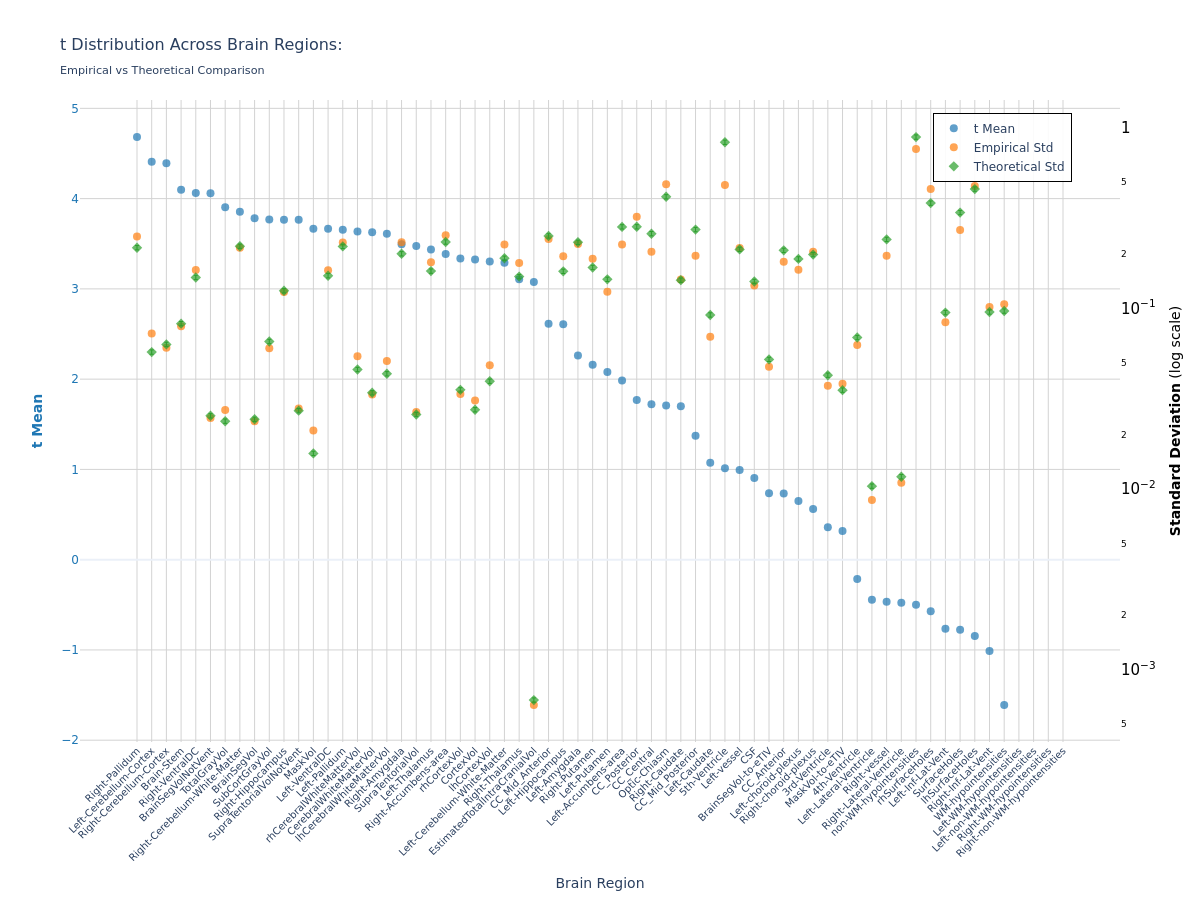

Saved difference plots to: <living-park>/results/numerical_validation/figures/baseline/subcortical_volume/difference_plots_t.png


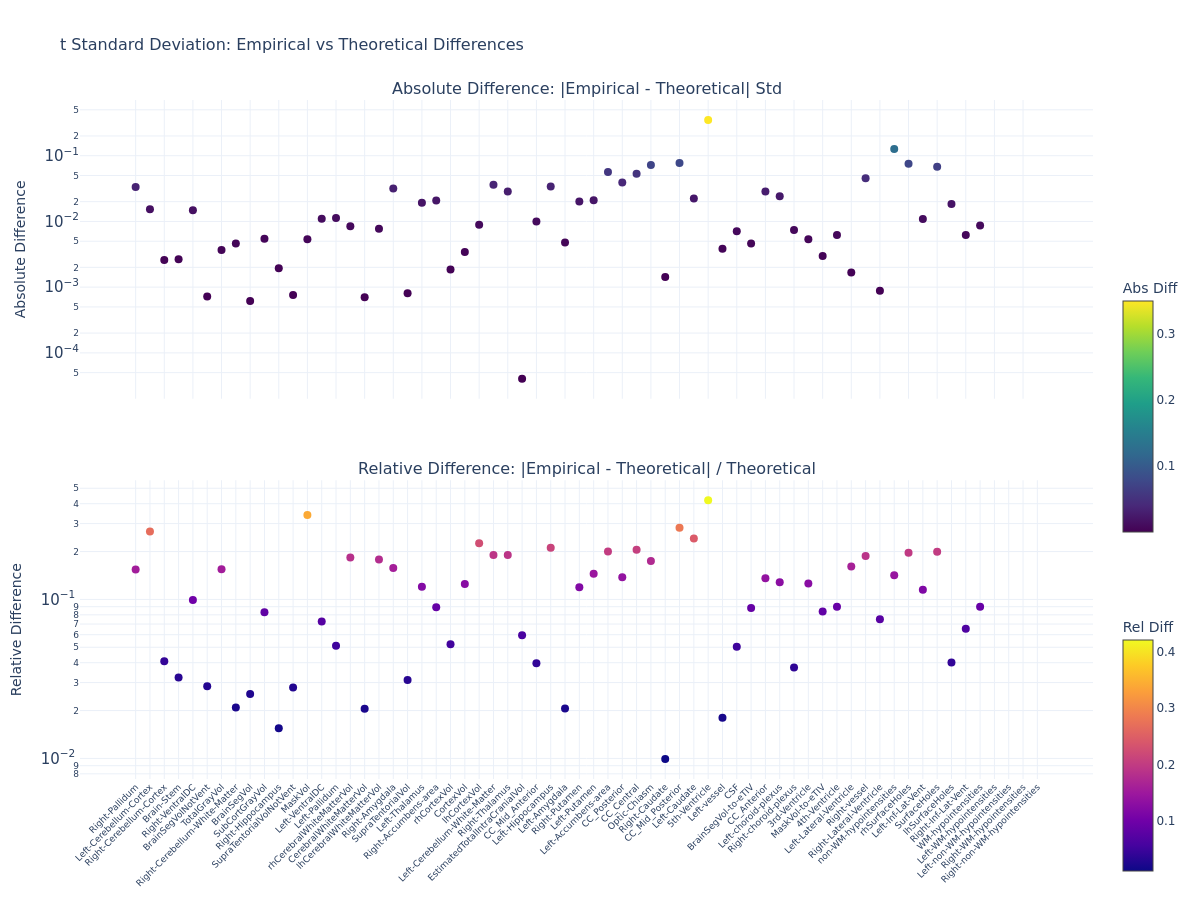

SUMMARY: Empirical vs Theoretical t Comparison

Absolute Differences (t_std_diff):
  Mean:   0.0249
  Median: 0.0088
  Min:    0.0000
  Max:    0.3505

Relative Differences (t_std_diff_rel):
  Mean:   12.13%
  Median: 11.70%
  Min:    0.99%
  Max:    42.10%

Top 5 Regions with Largest Relative Differences:
  5th-Ventricle: 42.10% (t=1.01)
  MaskVol: 34.00% (t=3.67)
  CC_Mid_Posterior: 28.28% (t=1.37)
  Left-Cerebellum-Cortex: 26.77% (t=4.41)
  Left-Caudate: 24.19% (t=1.07)


In [10]:
nu_nav = df_npvr[(df_npvr["timepoint"] == "baseline") & (df_npvr["group"] == "HC-PD")]
data_path = stats_dir / f"student_baseline_{METRIC}.parquet"
df, stats = get_test_stats(
    data_path,
    stat_functions_F,
    nu_nav,
    hemisphere=False,
    study="baseline",
    raw_values=True,
)
show_figure(stats, hemisphere=False, stat_name="t", study="baseline", metric=METRIC)

### p-value

Saved stats to: <living-park>/results/numerical_validation/csv/baseline/subcortical_volume/student_stats_t.csv
Saved theoretical distributions to: <living-park>/results/numerical_validation/csv/baseline/subcortical_volume/student_theoretical_distributions_t.csv


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,t_std_theoretical_high,t_var_theoretical,t_var_theoretical_low,t_var_theoretical_high,p-val_std_theoretical,p-val_std_theoretical_low,p-val_std_theoretical_high,p-val_var_theoretical,p-val_var_theoretical_low,p-val_var_theoretical_high
0,3rd-Ventricle,0.360445,0.037321,0.291712,0.430995,0.365686,0.719153,0.027865,0.667023,0.770873,...,0.043895,0.001823,0.001725,0.001927,0.031859,0.030991,0.032752,1.015019e-03,9.604707e-04,1.072693e-03
1,4th-Ventricle,-0.212726,0.062793,-0.349294,-0.120411,-0.208071,0.832115,0.048646,0.727282,0.904292,...,0.070930,0.004761,0.004505,0.005031,0.053654,0.052192,0.055157,2.878764e-03,2.724057e-03,3.042338e-03
2,5th-Ventricle,1.012477,0.482125,-0.142127,2.109336,1.000000,0.352622,0.217191,0.037226,0.887139,...,0.855957,0.693270,0.656013,0.732662,0.421355,0.409877,0.433160,1.775400e-01,1.679989e-01,1.876280e-01
3,Brain-Stem,4.097716,0.079717,3.956497,4.309010,4.099365,0.000064,0.000019,0.000026,0.000106,...,0.084687,0.006786,0.006422,0.007172,0.000022,0.000021,0.000022,4.674613e-10,4.423396e-10,4.940228e-10
4,BrainSegVol,3.783154,0.023715,3.744601,3.824936,3.782750,0.000207,0.000018,0.000176,0.000238,...,0.025014,0.000592,0.000560,0.000626,0.000019,0.000018,0.000019,3.555750e-10,3.364661e-10,3.757790e-10


Saved empirical vs theoretical differences to: <living-park>/results/numerical_validation/csv/baseline/subcortical_volume/student_empirical_vs_theoretical_differences_t.csv
Theoretical vs Empirical Distribution Analysis
Sample size: 198
Degrees of freedom: 194
Number of regions: 64

Empirical vs Theoretical Comparison:
  Mean t std relative diff: 12.128%
  Mean p-std relative diff: 13.640%


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,p-val_var_theoretical_low,p-val_var_theoretical_high,t_std_diff,t_std_diff_rel,t_std_diff_signed,t_std_diff_rel_signed,p-val_std_diff,p-val_std_diff_rel,p-val_std_diff_signed,p-val_std_diff_rel_signed
0,3rd-Ventricle,0.360445,0.037321,0.291712,0.430995,0.365686,0.719153,0.027865,0.667023,0.770873,...,9.604707e-04,1.072693e-03,0.005378,0.125943,-0.005378,-0.125943,3.994399e-03,0.125376,-3.994399e-03,-0.125376
1,4th-Ventricle,-0.212726,0.062793,-0.349294,-0.120411,-0.208071,0.832115,0.048646,0.727282,0.904292,...,2.724057e-03,3.042338e-03,0.006204,0.089919,-0.006204,-0.089919,5.008349e-03,0.093345,-5.008349e-03,-0.093345
2,5th-Ventricle,1.012477,0.482125,-0.142127,2.109336,1.000000,0.352622,0.217191,0.037226,0.887139,...,1.679989e-01,1.876280e-01,0.350503,0.420960,-0.350503,-0.420960,2.041644e-01,0.484543,-2.041644e-01,-0.484543
3,Brain-Stem,4.097716,0.079717,3.956497,4.309010,4.099365,0.000064,0.000019,0.000026,0.000106,...,4.423396e-10,4.940228e-10,0.002662,0.032311,-0.002662,-0.032311,2.389289e-06,0.110509,-2.389289e-06,-0.110509
4,BrainSegVol,3.783154,0.023715,3.744601,3.824936,3.782750,0.000207,0.000018,0.000176,0.000238,...,3.364661e-10,3.757790e-10,0.000618,0.025378,-0.000618,-0.025378,5.179270e-07,0.027466,-5.179270e-07,-0.027466


Saved distribution uncertainty plot to: <living-park>/results/numerical_validation/figures/baseline/subcortical_volume/distribution_uncertainty_p-val.png


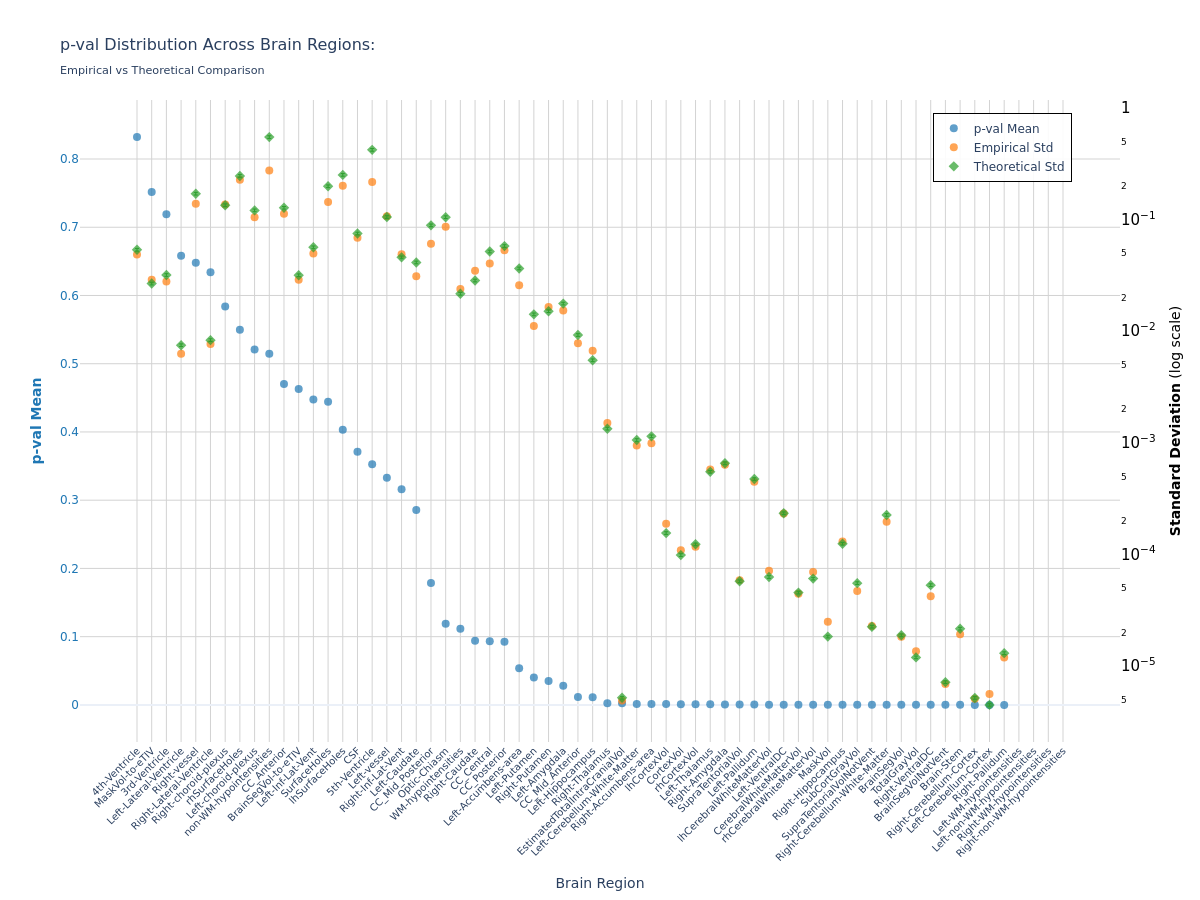

Saved difference plots to: <living-park>/results/numerical_validation/figures/baseline/subcortical_volume/difference_plots_p-val.png


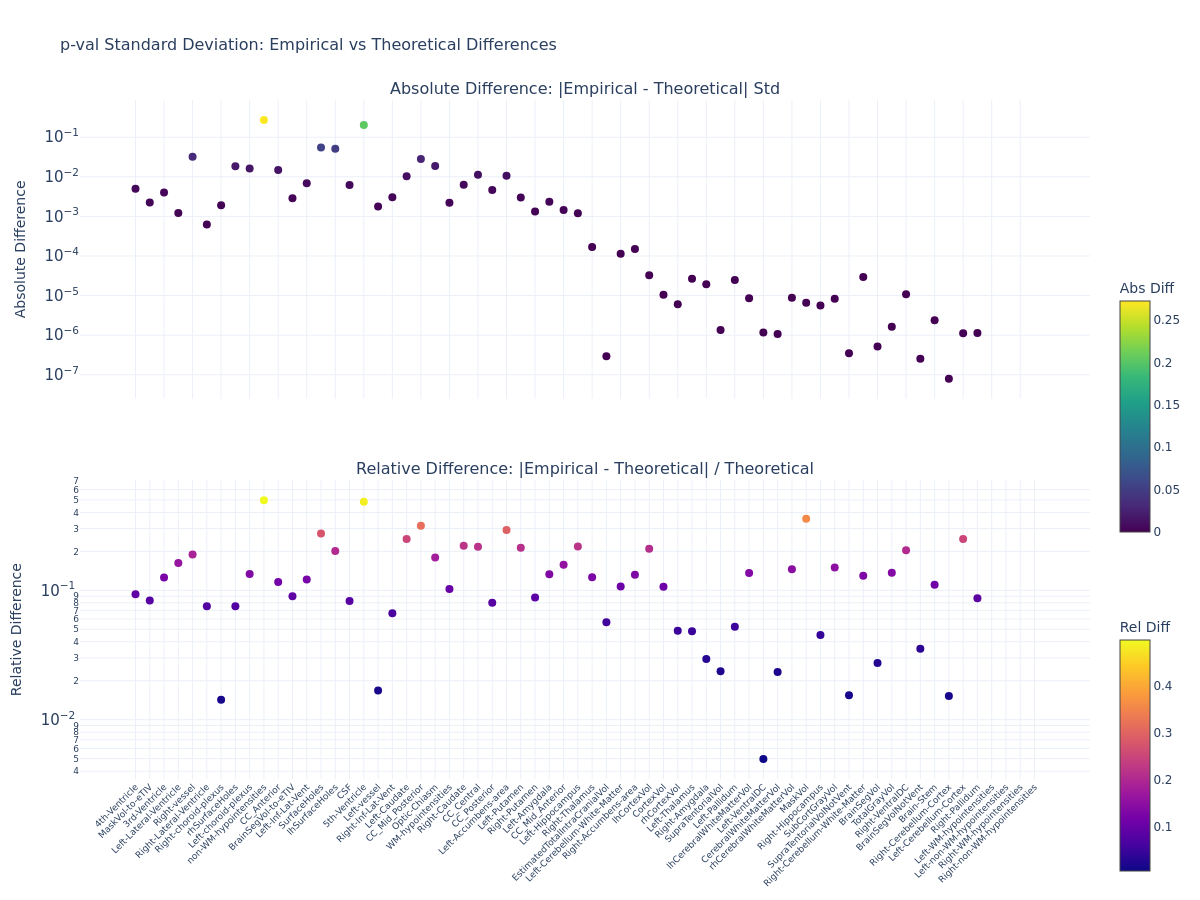

SUMMARY: Empirical vs Theoretical p-val Comparison

Absolute Differences (p-val_std_diff):
  Mean:   0.0134
  Median: 0.0012
  Min:    0.0000
  Max:    0.2727

Relative Differences (p-val_std_diff_rel):
  Mean:   13.64%
  Median: 11.86%
  Min:    0.50%
  Max:    49.73%

Top 5 Regions with Largest Relative Differences:
  non-WM-hypointensities: 49.73% (p-val=0.51)
  5th-Ventricle: 48.45% (p-val=0.35)
  MaskVol: 35.72% (p-val=0.00)
  CC_Mid_Posterior: 31.57% (p-val=0.18)
  Left-Accumbens-area: 29.22% (p-val=0.05)


In [11]:
nu_nav = df_npvr[(df_npvr["timepoint"] == "baseline") & (df_npvr["group"] == "HC-PD")]
data_path = stats_dir / f"student_baseline_{METRIC}.parquet"
df, stats = get_test_stats(
    data_path,
    stat_functions_F,
    nu_nav,
    hemisphere=False,
    study="baseline",
    raw_values=True,
)
show_figure(stats, hemisphere=False, stat_name="p-val", study="baseline", metric=METRIC)

![](../../numerical_validation/figures/baseline/distribution_uncertainty_p-val.png)
![](../../numerical_validation/figures/baseline/difference_plots_p-val.png)

## Longitudinal

### t-statistic

Saved stats to: <living-park>/results/numerical_validation/csv/longitudinal/subcortical_volume/student_stats_t.csv
Saved theoretical distributions to: <living-park>/results/numerical_validation/csv/longitudinal/subcortical_volume/student_theoretical_distributions_t.csv


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,t_std_theoretical_high,t_var_theoretical,t_var_theoretical_low,t_var_theoretical_high,p-val_std_theoretical,p-val_std_theoretical_low,p-val_std_theoretical_high,p-val_var_theoretical,p-val_var_theoretical_low,p-val_var_theoretical_high
0,3rd-Ventricle,-0.573849,0.487440,-1.566415,0.280203,-0.571222,0.583212,0.272877,0.118968,0.961650,...,0.408215,0.160210,0.154030,0.166640,0.260702,0.255625,0.265882,0.067965,0.065344,0.070693
1,4th-Ventricle,-1.800460,0.372960,-2.706513,-1.262165,-1.707852,0.090411,0.054329,0.007492,0.208590,...,0.450632,0.195234,0.187704,0.203069,0.089142,0.087406,0.090914,0.007946,0.007640,0.008265
2,5th-Ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brain-Stem,1.710399,0.342599,0.896561,2.351967,1.718981,0.107472,0.082889,0.019698,0.371119,...,0.436144,0.182882,0.175828,0.190222,0.099818,0.097874,0.101801,0.009964,0.009579,0.010363
4,BrainSegVol,-1.001249,0.211906,-1.528464,-0.552420,-0.992291,0.328200,0.101450,0.128097,0.581360,...,0.235481,0.053312,0.051256,0.055452,0.113510,0.111299,0.115765,0.012884,0.012387,0.013402


Saved empirical vs theoretical differences to: <living-park>/results/numerical_validation/csv/longitudinal/subcortical_volume/student_empirical_vs_theoretical_differences_t.csv
Theoretical vs Empirical Distribution Analysis
Sample size: 192
Degrees of freedom: 188
Number of regions: 68

Empirical vs Theoretical Comparison:
  Mean t std relative diff: 12.182%
  Mean p-std relative diff: 27.483%


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,p-val_var_theoretical_low,p-val_var_theoretical_high,t_std_diff,t_std_diff_rel,t_std_diff_signed,t_std_diff_rel_signed,p-val_std_diff,p-val_std_diff_rel,p-val_std_diff_signed,p-val_std_diff_rel_signed
0,3rd-Ventricle,-0.573849,0.487440,-1.566415,0.280203,-0.571222,0.583212,0.272877,0.118968,0.961650,...,0.065344,0.070693,0.087178,0.217802,0.087178,0.217802,0.012175,0.046700,0.012175,0.046700
1,4th-Ventricle,-1.800460,0.372960,-2.706513,-1.262165,-1.707852,0.090411,0.054329,0.007492,0.208590,...,0.007640,0.008265,0.068893,0.155919,-0.068893,-0.155919,0.034813,0.390532,-0.034813,-0.390532
2,5th-Ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brain-Stem,1.710399,0.342599,0.896561,2.351967,1.718981,0.107472,0.082889,0.019698,0.371119,...,0.009579,0.010363,0.085048,0.198875,-0.085048,-0.198875,0.016929,0.169602,-0.016929,-0.169602
4,BrainSegVol,-1.001249,0.211906,-1.528464,-0.552420,-0.992291,0.328200,0.101450,0.128097,0.581360,...,0.012387,0.013402,0.018987,0.082234,-0.018987,-0.082234,0.012060,0.106244,-0.012060,-0.106244


Saved distribution uncertainty plot to: <living-park>/results/numerical_validation/figures/longitudinal/subcortical_volume/distribution_uncertainty_t.png


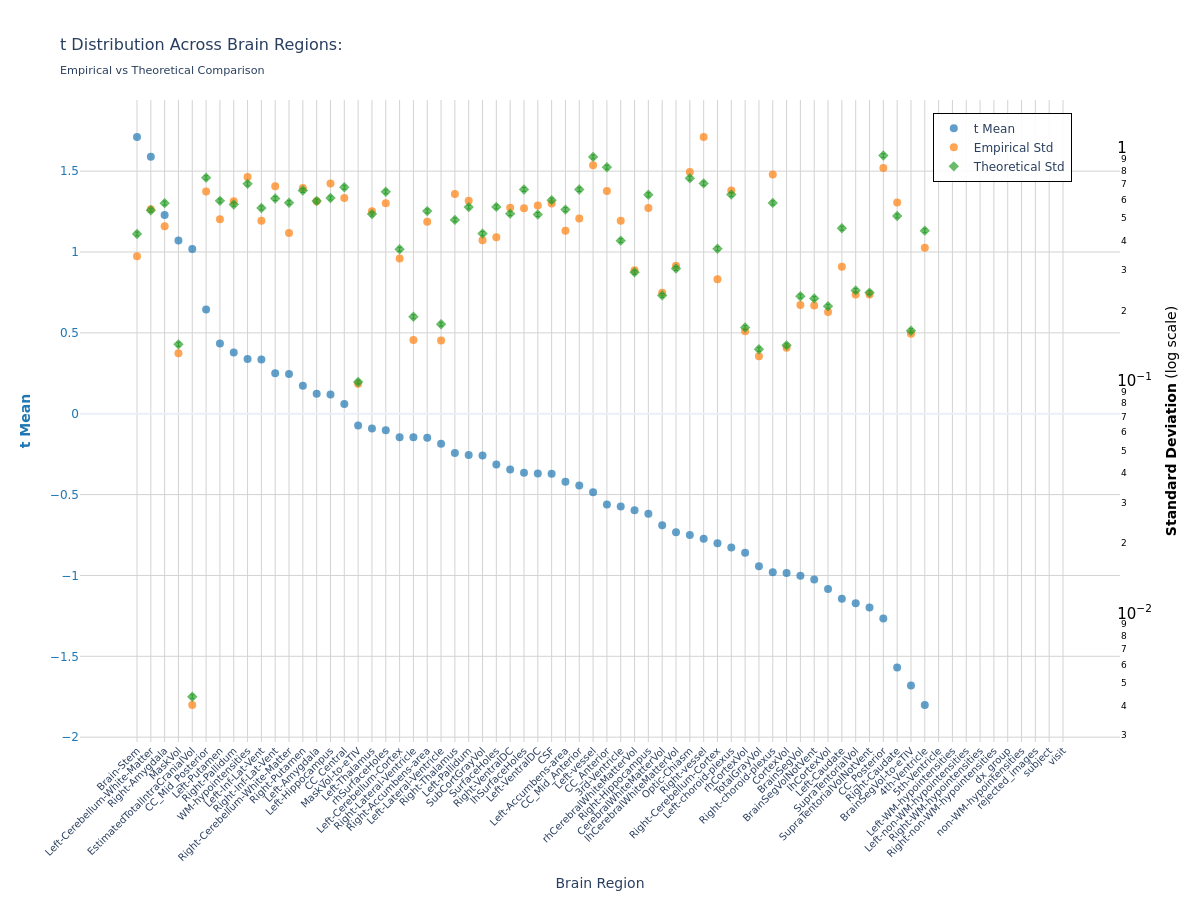

Saved difference plots to: <living-park>/results/numerical_validation/figures/longitudinal/subcortical_volume/difference_plots_t.png


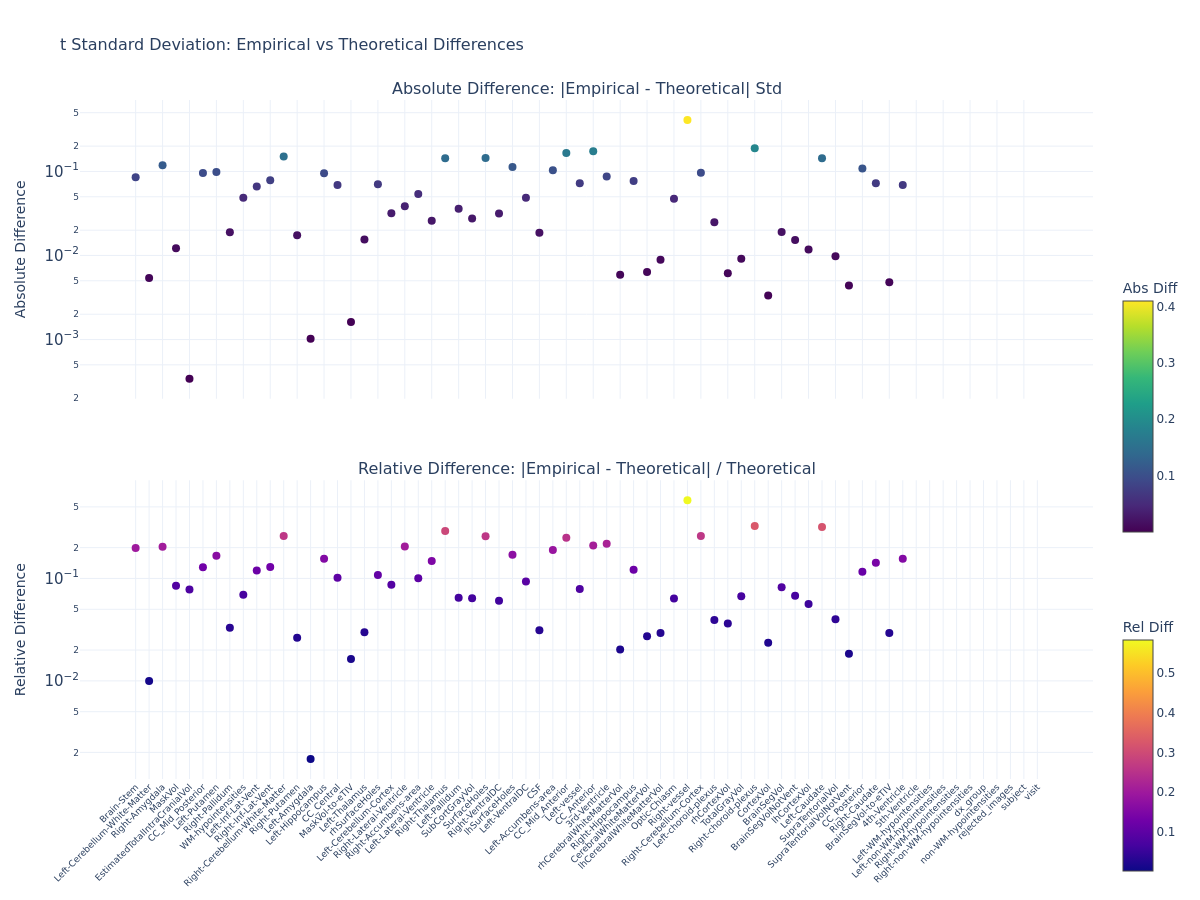

SUMMARY: Empirical vs Theoretical t Comparison

Absolute Differences (t_std_diff):
  Mean:   0.0640
  Median: 0.0480
  Min:    0.0003
  Max:    0.4102

Relative Differences (t_std_diff_rel):
  Mean:   12.18%
  Median: 9.02%
  Min:    0.17%
  Max:    58.14%

Top 5 Regions with Largest Relative Differences:
  Right-vessel: 58.14% (t=-0.77)
  Right-choroid-plexus: 32.56% (t=-0.98)
  Left-Caudate: 31.76% (t=-1.14)
  Right-Thalamus: 29.15% (t=-0.24)
  Right-Cerebellum-Cortex: 26.05% (t=-0.80)


In [12]:
nu_nav = df_npvr[(df_npvr["study"] == "longitudinal") & (df_npvr["group"] == "HC-PD")]
data_path = stats_dir / f"student_longitudinal_{METRIC}.parquet"
df, stats = get_test_stats(
    data_path,
    stat_functions_F,
    nu_nav,
    hemisphere=False,
    study="longitudinal",
    raw_values=True,
)
show_figure(stats, hemisphere=False, stat_name="t", study="longitudinal", metric=METRIC)

![](https://raw.githubusercontent.com/yohanchatelain/livingpark-numerical-variability/main/freesurfer-fuzzy/numerical_validation/figures/longitudinal/distribution_uncertainty_F.png)

![](https://raw.githubusercontent.com/yohanchatelain/livingpark-numerical-variability/main/freesurfer-fuzzy/numerical_validation/figures/longitudinal/difference_plots_F.png)

### p-value

Saved stats to: <living-park>/results/numerical_validation/csv/longitudinal/subcortical_volume/student_stats_t.csv
Saved theoretical distributions to: <living-park>/results/numerical_validation/csv/longitudinal/subcortical_volume/student_theoretical_distributions_t.csv


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,t_std_theoretical_high,t_var_theoretical,t_var_theoretical_low,t_var_theoretical_high,p-val_std_theoretical,p-val_std_theoretical_low,p-val_std_theoretical_high,p-val_var_theoretical,p-val_var_theoretical_low,p-val_var_theoretical_high
0,3rd-Ventricle,-0.573849,0.487440,-1.566415,0.280203,-0.571222,0.583212,0.272877,0.118968,0.961650,...,0.408215,0.160210,0.154030,0.166640,0.260702,0.255625,0.265882,0.067965,0.065344,0.070693
1,4th-Ventricle,-1.800460,0.372960,-2.706513,-1.262165,-1.707852,0.090411,0.054329,0.007492,0.208590,...,0.450632,0.195234,0.187704,0.203069,0.089142,0.087406,0.090914,0.007946,0.007640,0.008265
2,5th-Ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brain-Stem,1.710399,0.342599,0.896561,2.351967,1.718981,0.107472,0.082889,0.019698,0.371119,...,0.436144,0.182882,0.175828,0.190222,0.099818,0.097874,0.101801,0.009964,0.009579,0.010363
4,BrainSegVol,-1.001249,0.211906,-1.528464,-0.552420,-0.992291,0.328200,0.101450,0.128097,0.581360,...,0.235481,0.053312,0.051256,0.055452,0.113510,0.111299,0.115765,0.012884,0.012387,0.013402


Saved empirical vs theoretical differences to: <living-park>/results/numerical_validation/csv/longitudinal/subcortical_volume/student_empirical_vs_theoretical_differences_t.csv
Theoretical vs Empirical Distribution Analysis
Sample size: 192
Degrees of freedom: 188
Number of regions: 68

Empirical vs Theoretical Comparison:
  Mean t std relative diff: 12.182%
  Mean p-std relative diff: 27.483%


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,p-val_var_theoretical_low,p-val_var_theoretical_high,t_std_diff,t_std_diff_rel,t_std_diff_signed,t_std_diff_rel_signed,p-val_std_diff,p-val_std_diff_rel,p-val_std_diff_signed,p-val_std_diff_rel_signed
0,3rd-Ventricle,-0.573849,0.487440,-1.566415,0.280203,-0.571222,0.583212,0.272877,0.118968,0.961650,...,0.065344,0.070693,0.087178,0.217802,0.087178,0.217802,0.012175,0.046700,0.012175,0.046700
1,4th-Ventricle,-1.800460,0.372960,-2.706513,-1.262165,-1.707852,0.090411,0.054329,0.007492,0.208590,...,0.007640,0.008265,0.068893,0.155919,-0.068893,-0.155919,0.034813,0.390532,-0.034813,-0.390532
2,5th-Ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brain-Stem,1.710399,0.342599,0.896561,2.351967,1.718981,0.107472,0.082889,0.019698,0.371119,...,0.009579,0.010363,0.085048,0.198875,-0.085048,-0.198875,0.016929,0.169602,-0.016929,-0.169602
4,BrainSegVol,-1.001249,0.211906,-1.528464,-0.552420,-0.992291,0.328200,0.101450,0.128097,0.581360,...,0.012387,0.013402,0.018987,0.082234,-0.018987,-0.082234,0.012060,0.106244,-0.012060,-0.106244


Saved distribution uncertainty plot to: <living-park>/results/numerical_validation/figures/longitudinal/subcortical_volume/distribution_uncertainty_p-val.png


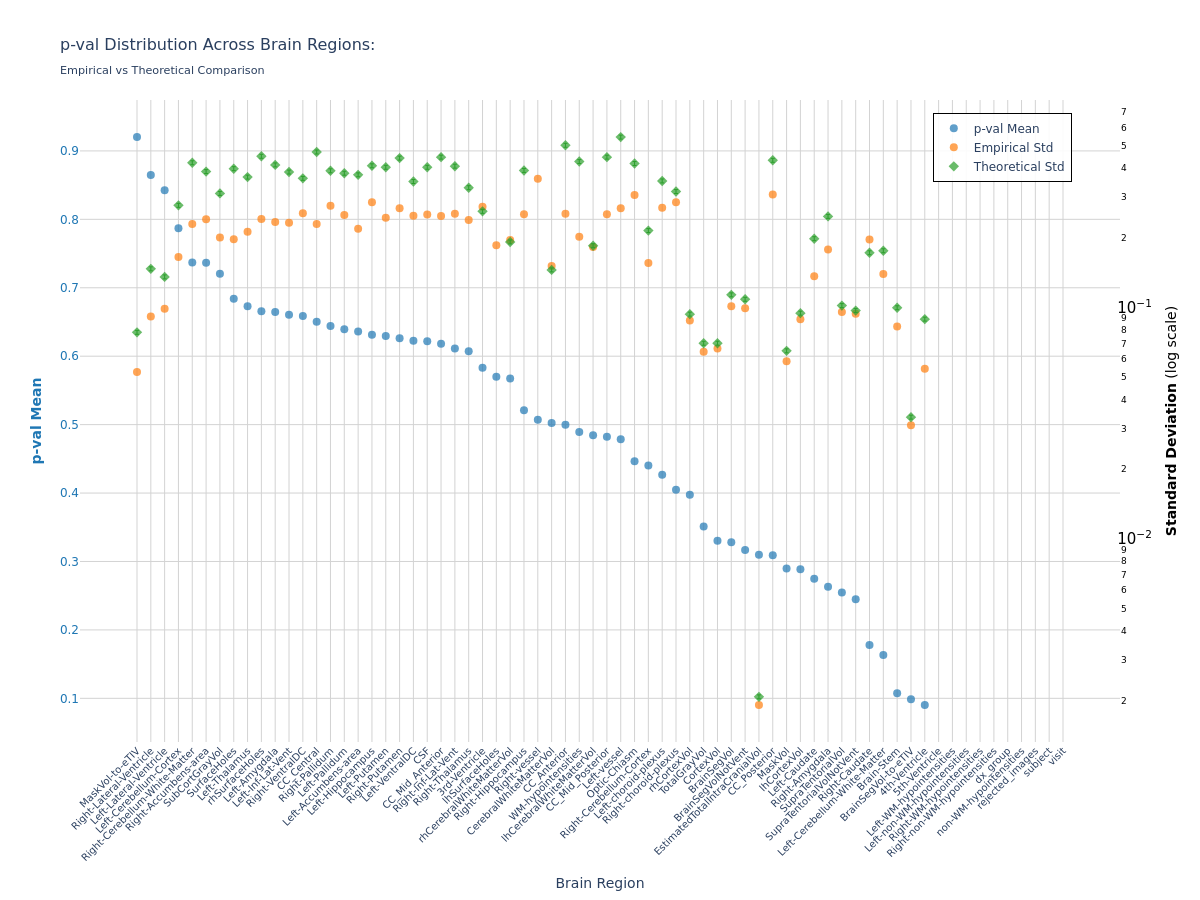

Saved difference plots to: <living-park>/results/numerical_validation/figures/longitudinal/subcortical_volume/difference_plots_p-val.png


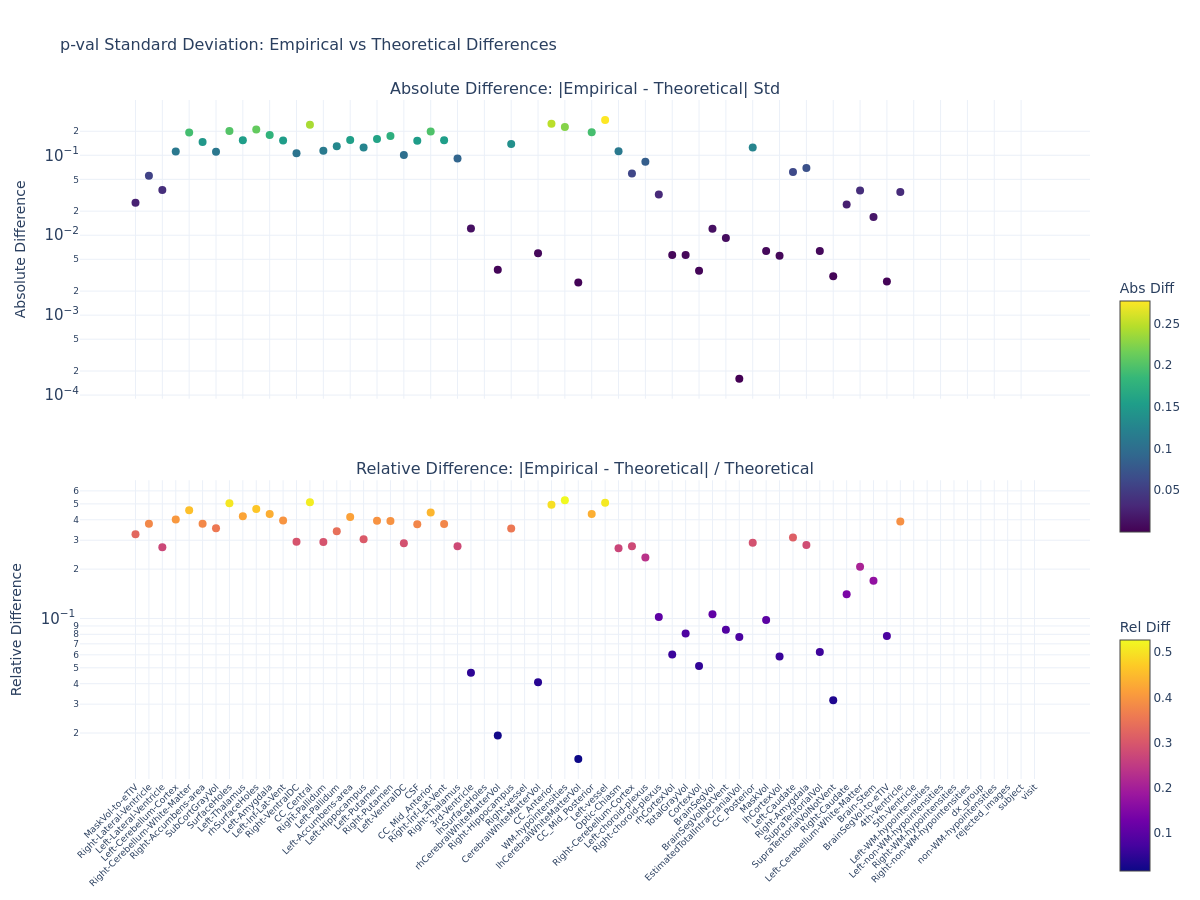

SUMMARY: Empirical vs Theoretical p-val Comparison

Absolute Differences (p-val_std_diff):
  Mean:   0.0947
  Median: 0.0960
  Min:    0.0002
  Max:    0.2771

Relative Differences (p-val_std_diff_rel):
  Mean:   27.48%
  Median: 29.36%
  Min:    1.39%
  Max:    52.66%

Top 5 Regions with Largest Relative Differences:
  WM-hypointensities: 52.66% (p-val=0.49)
  CC_Central: 51.20% (p-val=0.65)
  Left-vessel: 50.76% (p-val=0.48)
  SurfaceHoles: 50.50% (p-val=0.68)
  CC_Anterior: 49.47% (p-val=0.50)


In [13]:
nu_nav = df_npvr[(df_npvr["study"] == "longitudinal") & (df_npvr["group"] == "HC-PD")]
data_path = stats_dir / f"student_longitudinal_{METRIC}.parquet"
df, stats = get_test_stats(
    data_path,
    stat_functions_F,
    nu_nav,
    hemisphere=False,
    study="longitudinal",
    raw_values=True,
)
show_figure(
    stats, hemisphere=False, stat_name="p-val", study="longitudinal", metric=METRIC
)

![](../../numerical_validation/figures/longitudinal/distribution_uncertainty_p-val.png)
![](../../numerical_validation/figures/longitudinal/difference_plots_p-val.png)

![](../../navr/numerical_validation/figures/longitudinal/distribution_uncertainty_p-val.png)
![](../../navr/numerical_validation/figures/longitudinal/difference_plots_p-val.png)

![](../../navr/numerical_validation/figures/longitudinal/distribution_uncertainty_p-val.png)
![](../../navr/numerical_validation/figures/longitudinal/difference_plots_p-val.png)

## Aggregated results

In [14]:
# Aggregate empirical vs theoretical difference tables across studies
study_labels = ["baseline", "longitudinal"]
dfs = []
for study in study_labels:
    path = (
        csv_dir
        / study
        / METRIC
        / f"student_empirical_vs_theoretical_differences_{STAT_NAME}.csv"
    )
    df_study = pd.read_csv(path)
    df_study["study"] = study
    dfs.append(df_study)

df_aggregated = pd.concat(dfs, ignore_index=True)
df_aggregated = df_aggregated.dropna(subset=["metric"])

output_path = csv_dir / f"student_aggregated_{METRIC}.csv"
df_aggregated.to_csv(output_path, index=False)
print(f"Saved aggregated table ({len(df_aggregated)} rows) to: {anondir(output_path)}")
display(df_aggregated)

Saved aggregated table (128 rows) to: <living-park>/results/numerical_validation/csv/student_aggregated_subcortical_volume.csv


,region,t_mean,t_std,t_min,t_max,t_median,p-val_mean,p-val_std,p-val_min,p-val_max,...,p-val_var_theoretical_low,p-val_var_theoretical_high,t_std_diff,t_std_diff_rel,t_std_diff_signed,t_std_diff_rel_signed,p-val_std_diff,p-val_std_diff_rel,p-val_std_diff_signed,p-val_std_diff_rel_signed
0,3rd-Ventricle,0.360445,0.037321,0.291712,0.430995,0.365686,0.719153,0.027865,0.667023,0.770873,...,9.604707e-04,1.072693e-03,0.005378,0.125943,-0.005378,-0.125943,3.994399e-03,0.125376,-3.994399e-03,-0.125376
1,4th-Ventricle,-0.212726,0.062793,-0.349294,-0.120411,-0.208071,0.832115,0.048646,0.727282,0.904292,...,2.724057e-03,3.042338e-03,0.006204,0.089919,-0.006204,-0.089919,5.008349e-03,0.093345,-5.008349e-03,-0.093345
2,5th-Ventricle,1.012477,0.482125,-0.142127,2.109336,1.000000,0.352622,0.217191,0.037226,0.887139,...,1.679989e-01,1.876280e-01,0.350503,0.420960,-0.350503,-0.420960,2.041644e-01,0.484543,-2.041644e-01,-0.484543
3,Brain-Stem,4.097716,0.079717,3.956497,4.309010,4.099365,0.000064,0.000019,0.000026,0.000106,...,4.423396e-10,4.940228e-10,0.002662,0.032311,-0.002662,-0.032311,2.389289e-06,0.110509,-2.389289e-06,-0.110509
4,BrainSegVol,3.783154,0.023715,3.744601,3.824936,3.782750,0.000207,0.000018,0.000176,0.000238,...,3.364661e-10,3.757790e-10,0.000618,0.025378,-0.000618,-0.025378,5.179270e-07,0.027466,-5.179270e-07,-0.027466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,lhSurfaceHoles,-0.365739,0.551420,-1.111337,1.128599,-0.608492,0.569904,0.185968,0.260495,0.958664,...,NaN,NaN,0.113090,0.170185,-0.113090,-0.170185,NaN,NaN,NaN,NaN
125,non-WM-hypointensities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,rhCerebralWhiteMatterVol,-0.597605,0.298257,-1.109100,-0.101418,-0.586379,0.567338,0.195890,0.268978,0.919341,...,3.550931e-02,3.841620e-02,0.005911,0.020219,0.005911,0.020219,3.708441e-03,0.019297,3.708441e-03,0.019297
128,rhCortexVol,-0.859549,0.163144,-1.226898,-0.601935,-0.860782,0.397386,0.088040,0.221640,0.548119,...,8.439884e-03,9.130795e-03,0.006135,0.036242,-0.006135,-0.036242,5.653237e-03,0.060338,-5.653237e-03,-0.060338
